In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis as LDA,
)
from sklearn.preprocessing import StandardScaler

In [2]:
DATASET_NAME = "Whisper Base 3.0s"

DATASET_PATH = Path(
    "/Users/bhavaykhatri/Desktop/whisper_base/"
    "singBAP_dataset_whisper_whisper-base_3.0s.parquet"
)

OUTPUT_DIR = Path(
    "/Users/bhavaykhatri/Desktop/Assignments/"
    "audio_data_benchmarking_mml_lab/results/"
    "singbap_visualizations"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TARGET_EXPERIENCE = [
    "intermediate",
    "professional",
]

TARGET_CONDITIONS = [
    "correct",
    "arched_back",
    "hunched_back",
    "sideways",
    "chest_breathing",
    "over_articulation",
    "under_articulation",
]

In [3]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_PATH}"
    )

print(
    "File size:",
    round(
        DATASET_PATH.stat().st_size
        / (1024 ** 2),
        2,
    ),
    "MB",
)

df = pd.read_parquet(
    DATASET_PATH
)

print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

File size: 8.18 MB
Original shape: (4116, 13)
Columns: ['condition', 'experience', 'extractor', 'filename', 'filepath', 'frame_index', 'phonation', 'scale', 'singer', 'take', 'embedding', 'embedding_dtype', 'embedding_shape']


,condition,experience,extractor,filename,filepath,frame_index,phonation,scale,singer,take,embedding,embedding_dtype,embedding_shape
0,after_instruction,inexperienced,whisper_whisper-base,inex-1-after_instruction-glissando-1-mic-audio,/home/suvihaara/Documents/PhD/DATA/VTE/SingBAP...,0,,glissando,INEX-1,1,b'\x07\x9dU\xbe\xecA(\xbfX\xf9Q>J\x82\x8e\xbfg...,<f4,[512]
1,after_instruction,inexperienced,whisper_whisper-base,inex-1-after_instruction-glissando-2-mic-audio,/home/suvihaara/Documents/PhD/DATA/VTE/SingBAP...,0,,glissando,INEX-1,2,b'Z\xaee\xbe\x12\xbc)\xbf\x0c\xc45>\xe1\x82\x8...,<f4,[512]
2,after_instruction,inexperienced,whisper_whisper-base,inex-1-after_instruction-glissando-2-mic-audio,/home/suvihaara/Documents/PhD/DATA/VTE/SingBAP...,1,,glissando,INEX-1,2,b'\xc1=\x0b\xbd2m\x1b\xbfw2\xa0>\x9f\xfdk\xbf\...,<f4,[512]
3,after_instruction,inexperienced,whisper_whisper-base,inex-1-after_instruction-glissando-3-mic-audio,/home/suvihaara/Documents/PhD/DATA/VTE/SingBAP...,0,,glissando,INEX-1,3,b'\xc6]x\xbe\xf2\x82\x1e\xbf\xfdS>>\x83\x00\x8...,<f4,[512]
4,after_instruction,inexperienced,whisper_whisper-base,inex-1-after_instruction-glissando-3-mic-audio,/home/suvihaara/Documents/PhD/DATA/VTE/SingBAP...,1,,glissando,INEX-1,3,b'\x99\xea\x15\xbe?\xa81\xbf\x15\xc7U>\x80`\x8...,<f4,[512]


In [4]:
df_vis = df[
    df["experience"].isin(
        TARGET_EXPERIENCE
    )
].copy()

df_vis = df_vis[
    df_vis["condition"].isin(
        TARGET_CONDITIONS
    )
].copy()

df_vis = df_vis.reset_index(
    drop=True
)

print("Filtered shape:", df_vis.shape)

print("\nExperience distribution:")
print(
    df_vis["experience"].value_counts()
)

print("\nCondition distribution:")
print(
    df_vis["condition"]
    .value_counts()
    .reindex(TARGET_CONDITIONS)
)

Filtered shape: (3438, 13)

Experience distribution:
experience
intermediate    2794
professional     644
Name: count, dtype: int64

Condition distribution:
condition
correct               638
arched_back           405
hunched_back          556
sideways              521
chest_breathing       512
over_articulation     411
under_articulation    395
Name: count, dtype: int64


In [5]:
def decode_embedding(
    value,
    dtype=np.float32,
):
    if isinstance(
        value,
        (bytes, bytearray, memoryview),
    ):
        return np.frombuffer(
            value,
            dtype=dtype,
        ).copy()

    if isinstance(value, np.ndarray):
        return value.astype(
            dtype,
            copy=False,
        ).reshape(-1)

    if isinstance(value, (list, tuple)):
        return np.asarray(
            value,
            dtype=dtype,
        ).reshape(-1)

    raise TypeError(
        "Unsupported embedding type: "
        f"{type(value)}"
    )

In [6]:
decoded_embeddings = [
    decode_embedding(value)
    for value in df_vis["embedding"]
]

embedding_dimensions = {
    vector.shape[0]
    for vector in decoded_embeddings
}

if len(embedding_dimensions) != 1:
    raise ValueError(
        "Inconsistent embedding dimensions: "
        f"{sorted(embedding_dimensions)}"
    )

X = np.vstack(
    decoded_embeddings
)

y = (
    df_vis["condition"]
    .astype(str)
    .to_numpy()
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(np.unique(y)))
print("Embedding dimension:", X.shape[1])

X shape: (3438, 512)
y shape: (3438,)
Number of classes: 7
Embedding dimension: 512


In [7]:
finite_rows = np.isfinite(X).all(
    axis=1
)

removed_rows = (
    len(finite_rows)
    - finite_rows.sum()
)

print(
    "Rows containing NaN or infinity:",
    removed_rows,
)

if removed_rows > 0:
    X = X[finite_rows]
    y = y[finite_rows]

    df_vis = (
        df_vis.loc[finite_rows]
        .reset_index(drop=True)
    )

print("Final X shape:", X.shape)

Rows containing NaN or infinity: 0
Final X shape: (3438, 512)


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (3438, 512)


In [9]:
number_of_classes = len(
    np.unique(y)
)

number_of_components = min(
    3,
    number_of_classes - 1,
)

lda = LDA(
    n_components=number_of_components
)

X_lda = lda.fit_transform(
    X_scaled,
    y,
)

print("LDA projection shape:", X_lda.shape)

print(
    "Explained variance ratio:",
    lda.explained_variance_ratio_,
)

print(
    "Variance represented by LD1, LD2, and LD3:",
    round(
        lda.explained_variance_ratio_.sum()
        * 100,
        2,
    ),
    "%",
)

LDA projection shape: (3438, 3)
Explained variance ratio: [0.332086   0.21722363 0.12665789]
Variance represented by LD1, LD2, and LD3: 67.6 %


In [10]:
lda_df = pd.DataFrame({
    "LD1": X_lda[:, 0],
    "LD2": X_lda[:, 1],
    "LD3": X_lda[:, 2],
    "Condition": y,
    "Experience": (
        df_vis["experience"]
        .astype(str)
        .to_numpy()
    ),
    "Singer": (
        df_vis["singer"]
        .astype(str)
        .to_numpy()
    ),
    "Filename": (
        df_vis["filename"]
        .astype(str)
        .to_numpy()
    ),
})

lda_df.head()

,LD1,LD2,LD3,Condition,Experience,Singer,Filename
0,-0.652249,0.498349,0.492247,arched_back,intermediate,INTR-1,intr-1-breathy-arched_back-glissando-1-mic-audio
1,0.751957,0.538401,0.735101,arched_back,intermediate,INTR-1,intr-1-breathy-arched_back-glissando-2-mic-audio
2,0.053761,-0.402211,2.715927,arched_back,intermediate,INTR-1,intr-1-breathy-arched_back-glissando-3-mic-audio
3,-0.853718,0.688584,1.430582,arched_back,intermediate,INTR-1,intr-1-breathy-arched_back-glissando-4-mic-audio
4,-0.112087,-0.058551,0.557061,arched_back,intermediate,INTR-1,intr-1-breathy-arched_back-glissando-5-mic-audio


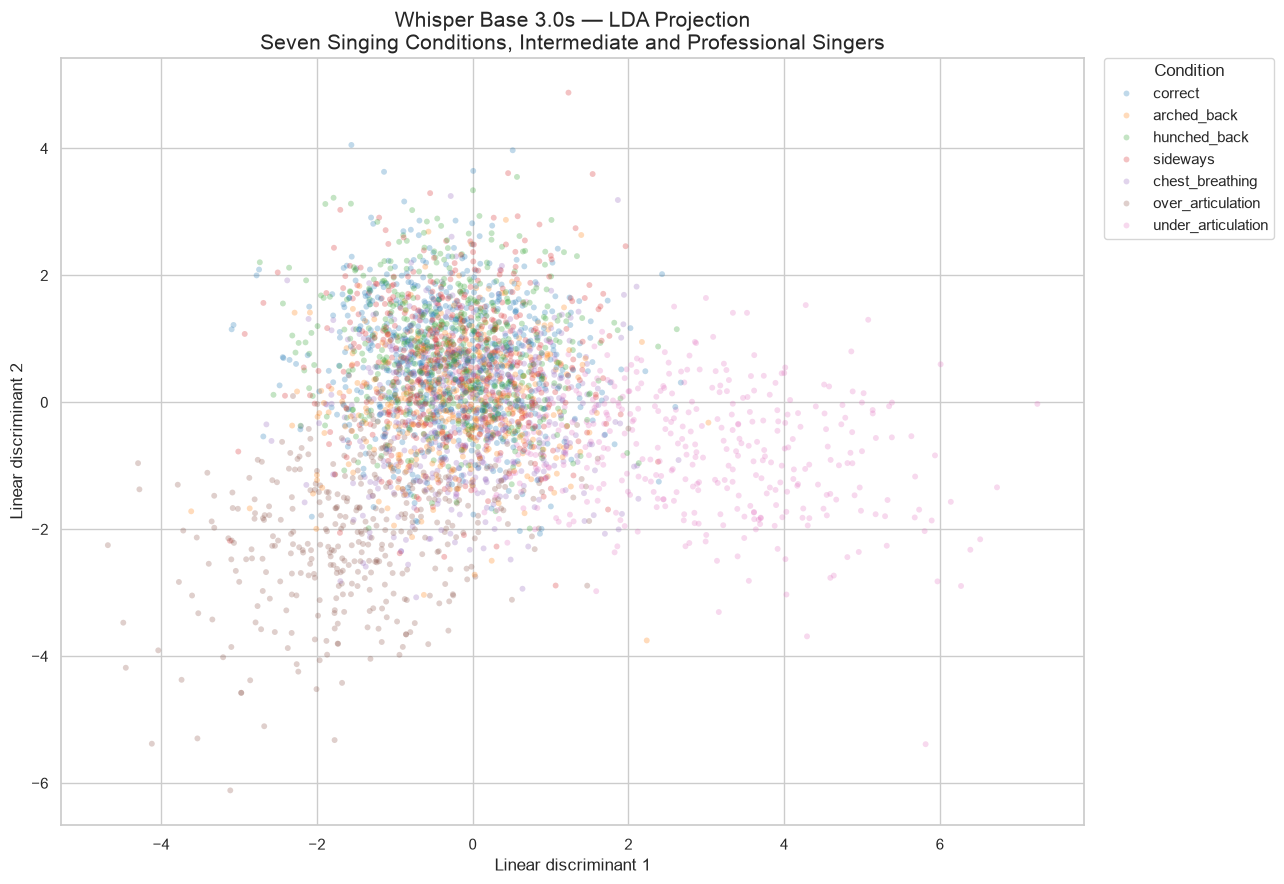

Saved: /Users/bhavaykhatri/Desktop/Assignments/audio_data_benchmarking_mml_lab/results/singbap_visualizations/whisper_3_0s_lda_2d_7_conditions.png


In [11]:
sns.set_theme(
    style="whitegrid"
)

plt.figure(
    figsize=(13, 9)
)

sns.scatterplot(
    data=lda_df,
    x="LD1",
    y="LD2",
    hue="Condition",
    hue_order=TARGET_CONDITIONS,
    palette="tab10",
    alpha=0.28,
    s=18,
    linewidth=0,
)

plt.title(
    "Whisper Base 3.0s — LDA Projection\n"
    "Seven Singing Conditions, "
    "Intermediate and Professional Singers",
    fontsize=15,
)

plt.xlabel(
    "Linear discriminant 1",
    fontsize=12,
)

plt.ylabel(
    "Linear discriminant 2",
    fontsize=12,
)

plt.legend(
    title="Condition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()

plot_2d_path = (
    OUTPUT_DIR
    / "whisper_3_0s_lda_2d_7_conditions.png"
)

plt.savefig(
    plot_2d_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", plot_2d_path)

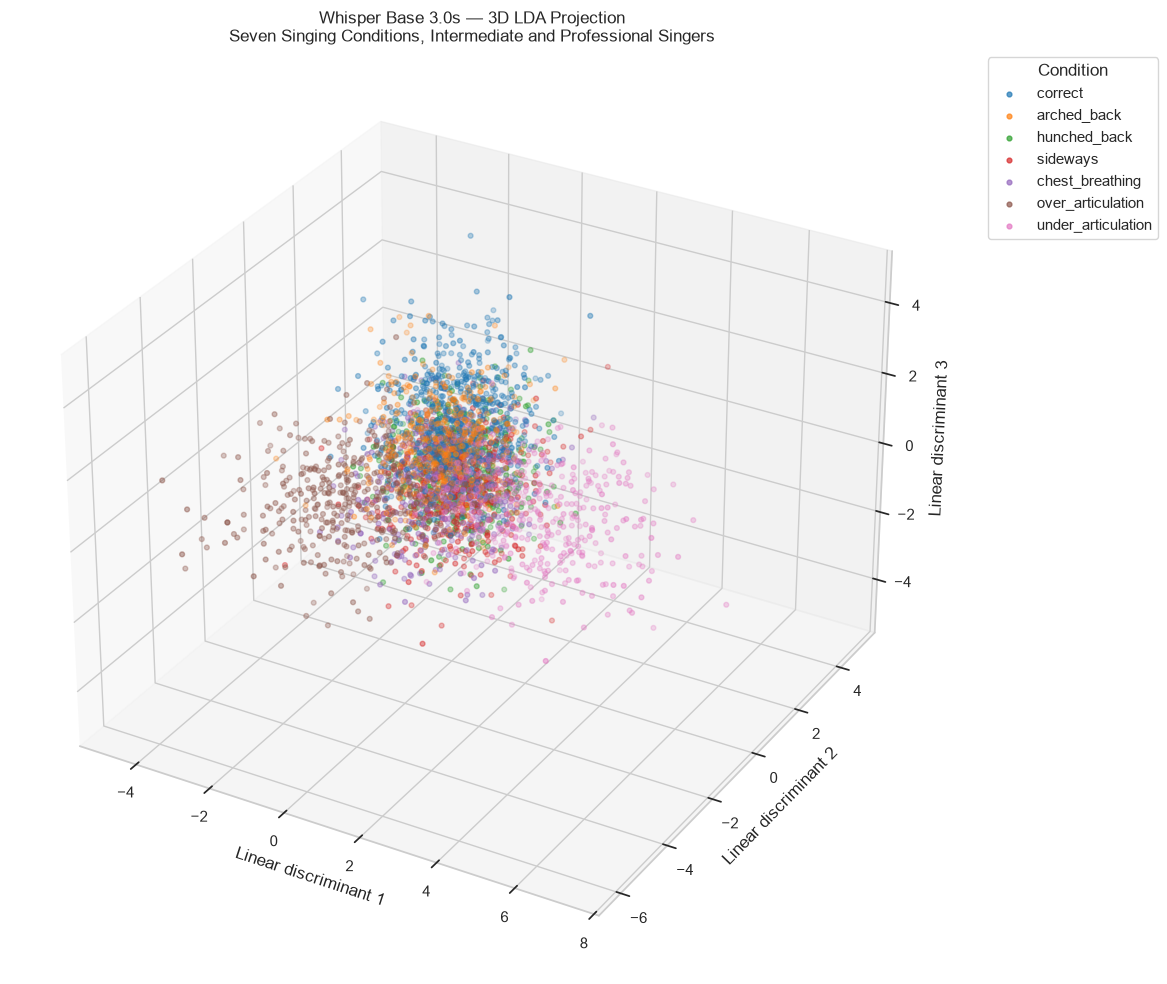

Saved: /Users/bhavaykhatri/Desktop/Assignments/audio_data_benchmarking_mml_lab/results/singbap_visualizations/whisper_3_0s_lda_3d_7_conditions.png


In [12]:
from mpl_toolkits.mplot3d import Axes3D

palette = sns.color_palette(
    "tab10",
    n_colors=len(TARGET_CONDITIONS),
)

fig = plt.figure(
    figsize=(13, 10)
)

ax = fig.add_subplot(
    111,
    projection="3d",
)

for condition, color in zip(
    TARGET_CONDITIONS,
    palette,
):
    subset = lda_df[
        lda_df["Condition"] == condition
    ]

    ax.scatter(
        subset["LD1"],
        subset["LD2"],
        subset["LD3"],
        label=condition,
        alpha=0.7,
        s=12,
        color=color,
    )

ax.set_xlabel(
    "Linear discriminant 1"
)

ax.set_ylabel(
    "Linear discriminant 2"
)

ax.set_zlabel(
    "Linear discriminant 3"
)

ax.set_title(
    "Whisper Base 3.0s — 3D LDA Projection\n"
    "Seven Singing Conditions, "
    "Intermediate and Professional Singers"
)

ax.legend(
    title="Condition",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()

plot_3d_path = (
    OUTPUT_DIR
    / "whisper_3_0s_lda_3d_7_conditions.png"
)

plt.savefig(
    plot_3d_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", plot_3d_path)

In [13]:
coordinates_path = (
    OUTPUT_DIR
    / "whisper_3_0s_lda_coordinates.csv"
)

lda_df.to_csv(
    coordinates_path,
    index=False,
)

print("Saved:", coordinates_path)

Saved: /Users/bhavaykhatri/Desktop/Assignments/audio_data_benchmarking_mml_lab/results/singbap_visualizations/whisper_3_0s_lda_coordinates.csv


In [14]:
summary_df = pd.DataFrame({
    "Dataset": [DATASET_NAME],
    "Samples": [X.shape[0]],
    "Original Features": [X.shape[1]],
    "Classes": [number_of_classes],

    "LD1 Explained Variance": [
        lda.explained_variance_ratio_[0]
    ],

    "LD2 Explained Variance": [
        lda.explained_variance_ratio_[1]
    ],

    "LD3 Explained Variance": [
        lda.explained_variance_ratio_[2]
    ],

    "Total Explained Variance": [
        lda.explained_variance_ratio_.sum()
    ],
})

summary_path = (
    OUTPUT_DIR
    / "whisper_3_0s_lda_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

summary_df

,Dataset,Samples,Original Features,Classes,LD1 Explained Variance,LD2 Explained Variance,LD3 Explained Variance,Total Explained Variance
0,Whisper Base 3.0s,3438,512,7,0.332086,0.217224,0.126658,0.675968
